# Libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("/Users/mac/Desktop/python project/Movie Data.csv")
# print(df.head())
print(df.columns)

df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')


Index(['Movie Title', 'Release Date', 'Wikipedia URL', 'Genre (1)',
       'Genre (2)', 'Director (1)', 'Director (2)', 'Cast (1)', 'Cast (2)',
       'Cast (3)', 'Cast (4)', 'Cast (5)', 'Budget ($)',
       'Box Office Revenue ($)'],
      dtype='str')


# Budget vs Box Office Revenue

/var/folders/_5/99515_mj3sj6sxffzzmt_fd80000gn/T/ipykernel_18046/967534407.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


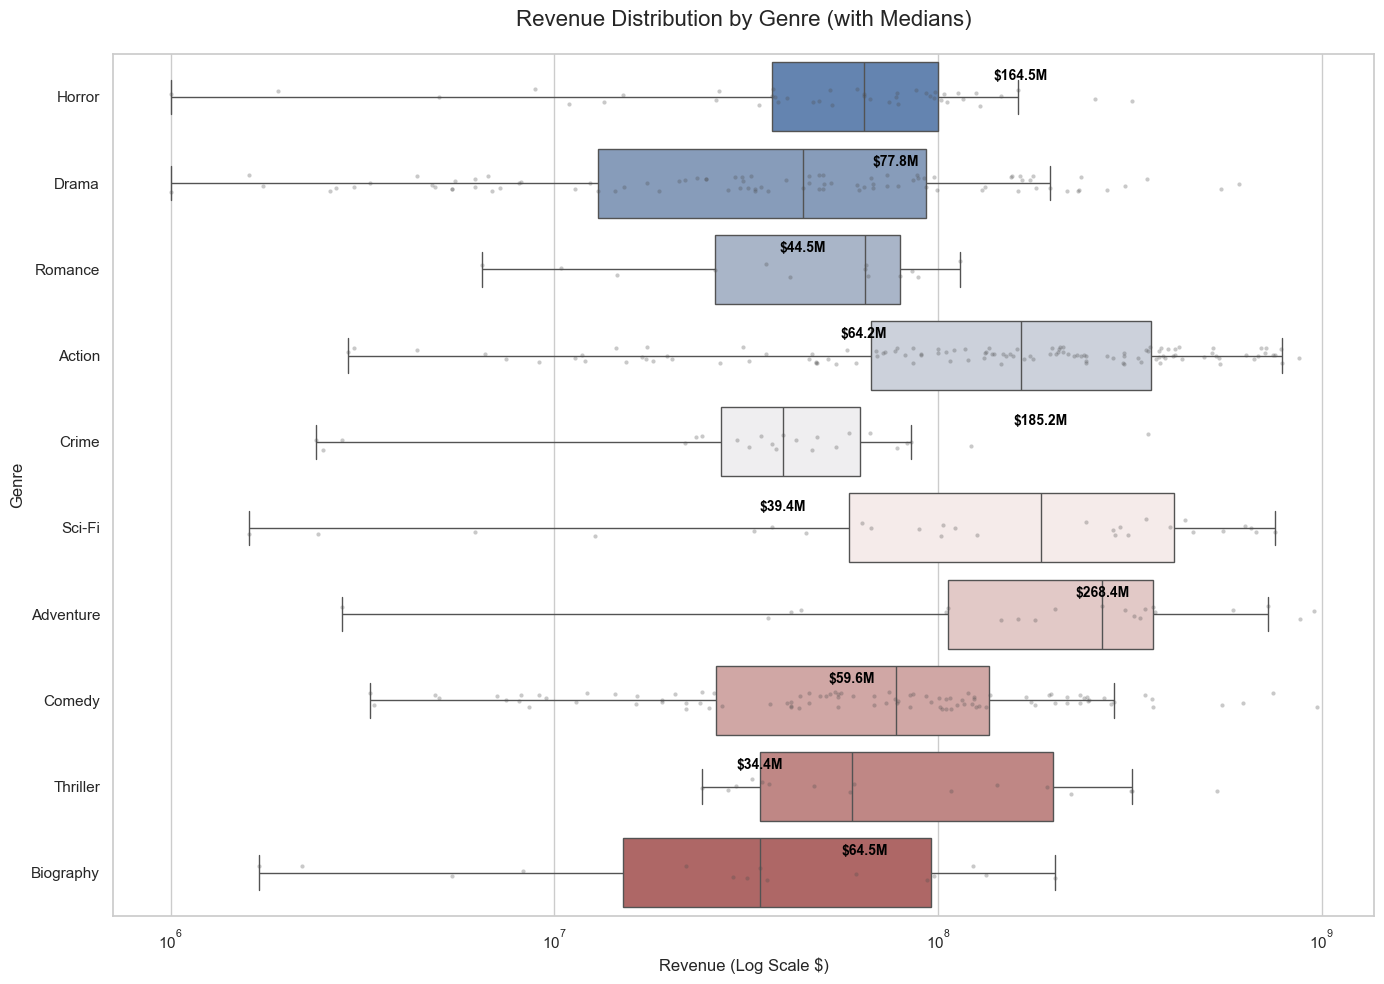

In [78]:
cols = ['Budget ($)', 'Box Office Revenue ($)']
for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# 2. Filter for top 10 genres by count to avoid clutter
top_genres = df['Genre (1)'].value_counts().nlargest(10).index
df_top = df[df['Genre (1)'].isin(top_genres)]

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

# 3. Draw the Box Plot (Simplified colors)
ax = sns.boxplot(
    data=df_top, x='Box Office Revenue ($)', y='Genre (1)', 
    palette="vlag", showfliers=False, whis=1.5
)

# 4. ADD CLARITY: Overlay individual movie points (Strip Plot)
sns.stripplot(
    data=df_top, x='Box Office Revenue ($)', y='Genre (1)', 
    size=3, color=".3", linewidth=0, alpha=0.3
)

# 5. ADD VALUES: Label the Median for each genre
medians = df_top.groupby('Genre (1)')['Box Office Revenue ($)'].median()
for i, genre in enumerate(top_genres):
    median_val = medians[genre]
    if pd.notnull(median_val):
        # Position the text slightly above the median line
        plt.text(median_val, i - 0.2, f'${median_val/1e6:.1f}M', 
                 weight='bold', color='black', ha='center', fontsize=10)

# 6. Formatting
plt.xscale('log')
plt.title("Revenue Distribution by Genre (with Medians)", fontsize=16, pad=20)
plt.xlabel("Revenue (Log Scale $)", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()
plt.show()

# Top Genres

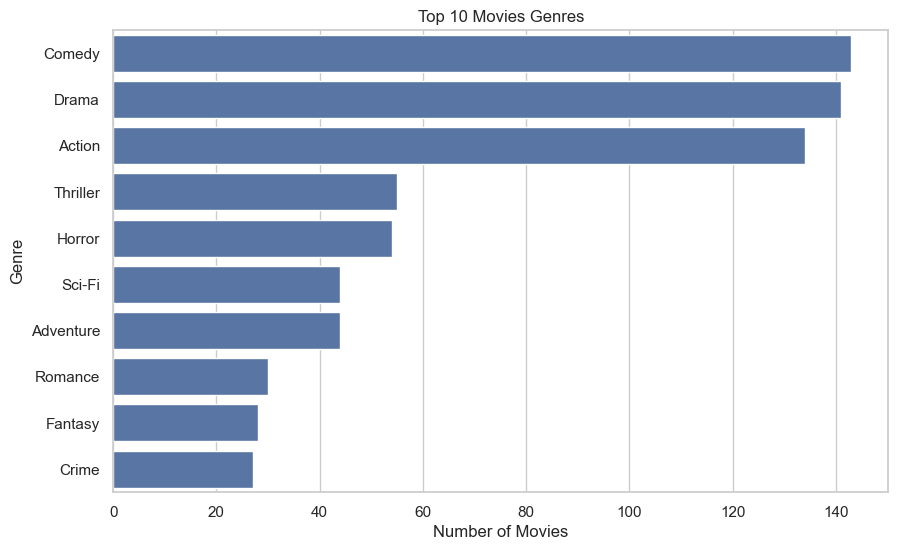

In [79]:
genres = pd.concat([df['Genre (1)'], df['Genre (2)']]).dropna()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Movies Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()


# Top Directors

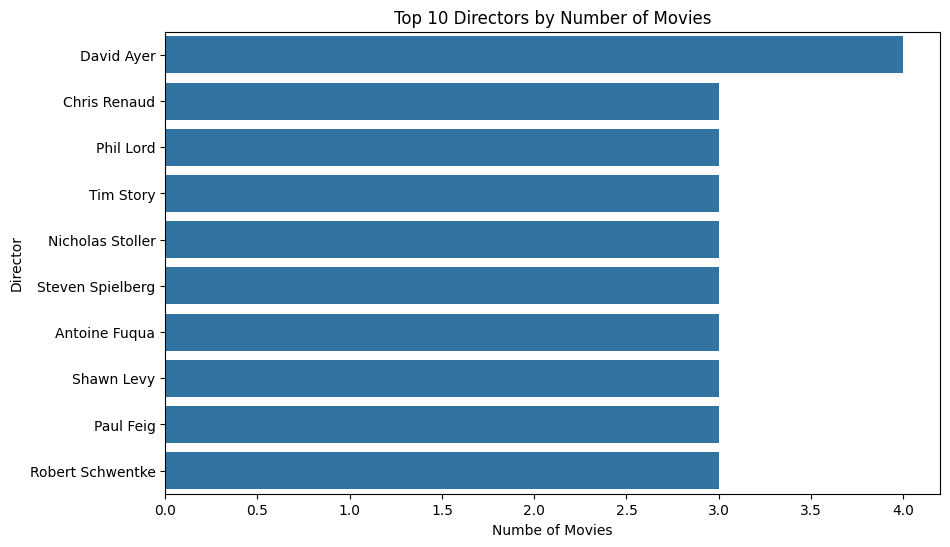

In [12]:
directors = pd.concat([df['Director (1)'],df['Director (2)']]).dropna()
top_directors= directors.value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors by Number of Movies")
plt.xlabel("Numbe of Movies")
plt.ylabel("Director")
plt.show()
 

# Top Cast Members

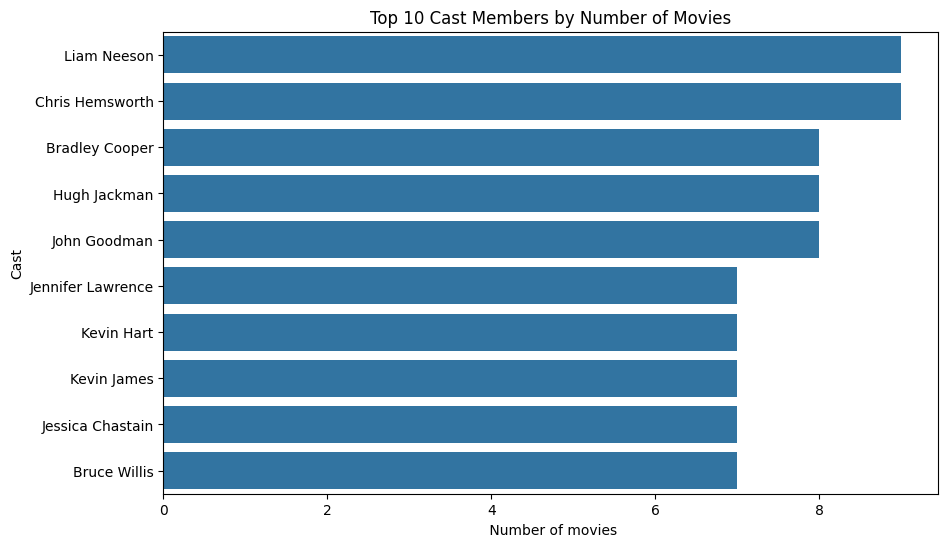

In [13]:
cast_columns = ['Cast (1)', 'Cast (2)', 'Cast (3)', 'Cast (4)', 'Cast (5)']
cast_list = pd.concat([df[col] for col in cast_columns]).dropna()
top_cast = cast_list.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cast.values, y=top_cast.index)
plt.title("Top 10 Cast Members by Number of Movies")
plt.xlabel(" Number of movies")
plt.ylabel("Cast")
plt.show()


# Box Office Performance By Genre

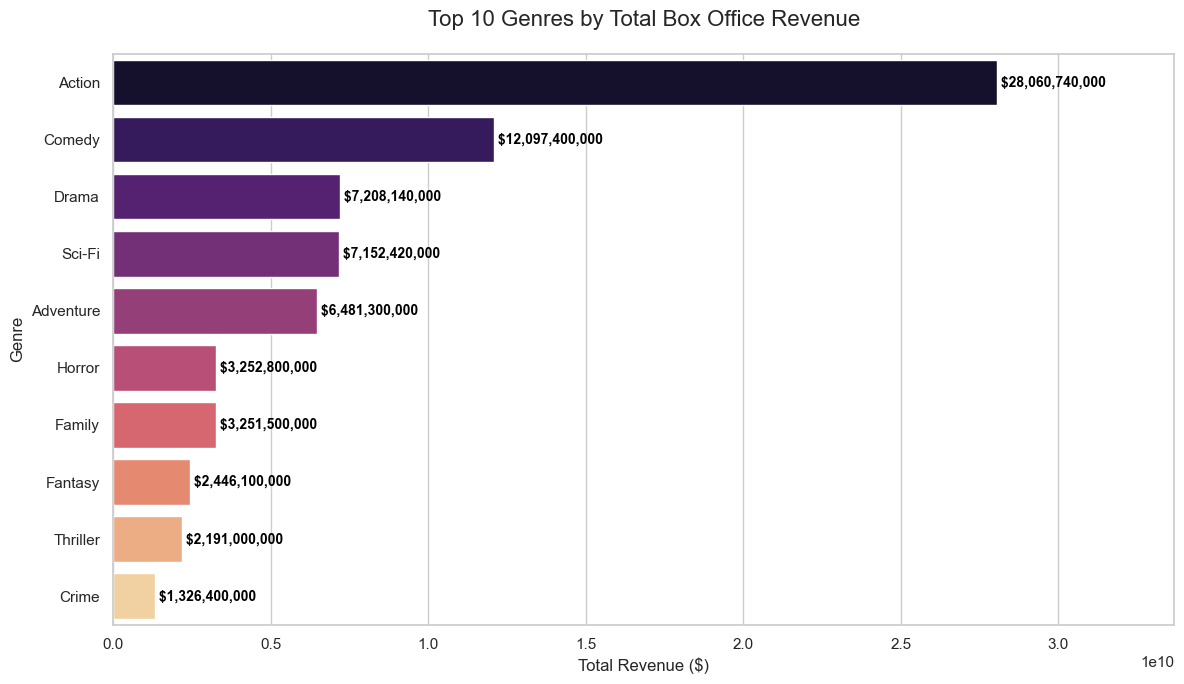

In [71]:
df['Box Office Revenue ($)'] = df['Box Office Revenue ($)'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['Box Office Revenue ($)'] = pd.to_numeric(df['Box Office Revenue ($)'], errors='coerce')

# 2. Group by Genre and sum the revenue
# Using 'Genre (1)' as the primary category
genre_revenue = df.groupby('Genre (1)')['Box Office Revenue ($)'].sum().sort_values(ascending=False).head(10)

# 3. Create the Plot
if not genre_revenue.empty:
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid") # Makes it "good and clean"

    ax = sns.barplot(
        x=genre_revenue.values, 
        y=genre_revenue.index, 
        hue=genre_revenue.index,
        palette="magma",
        legend=False
    )

    # 4. Add data labels so we don't need a log scale
    for i, v in enumerate(genre_revenue.values):
        ax.text(v, i, f' ${v:,.0f}', va='center', fontsize=10, fontweight='bold', color='black')

    # 5. Final touches
    plt.title("Top 10 Genres by Total Box Office Revenue", fontsize=16, pad=20)
    plt.xlabel("Total Revenue ($)", fontsize=12)
    plt.ylabel("Genre", fontsize=12)
    
    # Add extra space for the labels
    plt.xlim(0, genre_revenue.max() * 1.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("Data still empty. Please run: print(df['Box Office Revenue ($)'].head())")